In [1]:
# import pandas as pd
# import numpy as np
# import os
# import warnings
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import ttest_ind
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
# from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import f1_score

# warnings.filterwarnings('ignore')
# sns.set_theme(style="whitegrid")

# def load_and_prepare_data(base_dir):
#     """Load data and return separate correct and misclassified dataframes for multiple undersampling"""
#     paths = ['wtwt_test_processed.csv', 'except_wtwt_test_processed_mapped_data.csv']
#     indices = ['wtwt_correctly_classified_indices.npy', 'wtwt_misclassified_indices.npy',
#                'except_wtwt_correctly_classified_indices.npy', 'except_wtwt_misclassified_indices.npy']

#     df_wtwt = pd.read_csv(os.path.join(base_dir, paths[0]))
#     df_except = pd.read_csv(os.path.join(base_dir, paths[1]))

#     wtwt_correct = df_wtwt.iloc[np.load(os.path.join(base_dir, indices[0]))]
#     wtwt_mis = df_wtwt.iloc[np.load(os.path.join(base_dir, indices[1]))]
#     except_correct = df_except.iloc[np.load(os.path.join(base_dir, indices[2]))]
#     except_mis = df_except.iloc[np.load(os.path.join(base_dir, indices[3]))]

#     df_correct = pd.concat([wtwt_correct, except_correct]).assign(label=1)
#     df_mis = pd.concat([wtwt_mis, except_mis]).assign(label=0)
    
#     print(f"Correctly classified: {len(df_correct)}, Misclassified: {len(df_mis)}")
    
#     return df_correct.reset_index(drop=True), df_mis.reset_index(drop=True)

# def create_balanced_datasets_all_data(df_correct, df_mis):
#     """Create balanced datasets using ALL correctly classified examples"""
#     balanced_datasets = []
#     misclassified_stance_counts = df_mis['stance'].value_counts()
    
#     # Calculate how many complete iterations we can do
#     min_iterations = len(df_correct) // len(df_mis)
#     remaining_examples = len(df_correct) % len(df_mis)
    
#     print(f"Will create {min_iterations} full iterations + 1 partial iteration")
#     print(f"Full iterations will use {min_iterations * len(df_mis)} examples")
#     print(f"Partial iteration will use remaining {remaining_examples} examples")
    
#     # Create full iterations
#     for iteration in range(min_iterations):
#         df_correct_sampled_parts = []
        
#         for stance in misclassified_stance_counts.index:
#             stance_correct = df_correct[df_correct['stance'] == stance]
#             stance_misclassified_count = misclassified_stance_counts[stance]
            
#             if len(stance_correct) > 0:
#                 total_available = len(stance_correct)
#                 samples_per_iteration = min(stance_misclassified_count, total_available // min_iterations)
                
#                 if samples_per_iteration > 0:
#                     start_idx = iteration * samples_per_iteration
#                     end_idx = start_idx + samples_per_iteration
#                     sampled = stance_correct.iloc[start_idx:end_idx]
#                     df_correct_sampled_parts.append(sampled)
        
#         if df_correct_sampled_parts:
#             df_correct_sampled = pd.concat(df_correct_sampled_parts)
#             df_balanced = pd.concat([df_correct_sampled, df_mis]).reset_index(drop=True)
#             balanced_datasets.append(df_balanced)
    
#     # Create partial iteration with remaining examples
#     if remaining_examples > 0:
#         df_correct_sampled_parts = []
        
#         for stance in misclassified_stance_counts.index:
#             stance_correct = df_correct[df_correct['stance'] == stance]
#             stance_misclassified_count = misclassified_stance_counts[stance]
            
#             if len(stance_correct) > 0:
#                 total_available = len(stance_correct)
#                 samples_per_iteration = min(stance_misclassified_count, total_available // min_iterations)
                
#                 # Get remaining examples for this stance
#                 used_examples = min_iterations * samples_per_iteration
#                 remaining_for_stance = total_available - used_examples
                
#                 if remaining_for_stance > 0:
#                     # Take proportional amount from remaining
#                     proportion = stance_misclassified_count / len(df_mis)
#                     take_remaining = min(remaining_for_stance, int(remaining_examples * proportion))
                    
#                     if take_remaining > 0:
#                         start_idx = used_examples
#                         end_idx = start_idx + take_remaining
#                         sampled = stance_correct.iloc[start_idx:end_idx]
#                         df_correct_sampled_parts.append(sampled)
        
#         if df_correct_sampled_parts:
#             df_correct_sampled = pd.concat(df_correct_sampled_parts)
#             df_balanced = pd.concat([df_correct_sampled, df_mis]).reset_index(drop=True)
#             balanced_datasets.append(df_balanced)
    
#     return balanced_datasets


# def create_balanced_datasets(df_correct, df_mis, n_iterations):
#     """Create multiple balanced datasets using different undersampling"""
#     balanced_datasets = []
#     misclassified_stance_counts = df_mis['stance'].value_counts()
    
#     # Calculate how many examples we can sample per iteration for each stance
#     correct_stance_counts = df_correct['stance'].value_counts()
    
#     for iteration in range(n_iterations):
#         # For each stance, sample without replacement across iterations
#         df_correct_sampled_parts = []
        
#         for stance in misclassified_stance_counts.index:
#             stance_correct = df_correct[df_correct['stance'] == stance]
#             stance_misclassified_count = misclassified_stance_counts[stance]
            
#             if len(stance_correct) > 0:
#                 # Calculate the range for this iteration
#                 total_available = len(stance_correct)
#                 samples_per_iteration = min(stance_misclassified_count, total_available // n_iterations)
                
#                 if samples_per_iteration > 0:
#                     start_idx = (iteration * samples_per_iteration) % total_available
#                     end_idx = min(start_idx + samples_per_iteration, total_available)
                    
#                     # If we go beyond the end, wrap around
#                     if end_idx - start_idx < samples_per_iteration and total_available > samples_per_iteration:
#                         indices = list(range(start_idx, total_available)) + list(range(0, samples_per_iteration - (total_available - start_idx)))
#                         sampled = stance_correct.iloc[indices]
#                     else:
#                         sampled = stance_correct.iloc[start_idx:end_idx]
                    
#                     df_correct_sampled_parts.append(sampled)
        
#         if df_correct_sampled_parts:
#             df_correct_sampled = pd.concat(df_correct_sampled_parts)
#             df_balanced = pd.concat([df_correct_sampled, df_mis]).reset_index(drop=True)
#             balanced_datasets.append(df_balanced)
    
#     return balanced_datasets

# def save_top_features_for_iteration(df_stance, feature_cols, models, stance_name, iteration_dir):
#     """Save top features analysis for a single iteration - similar to original format"""
#     X = df_stance[feature_cols]
#     y = df_stance['label']

#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
#     imputer = SimpleImputer(strategy='median')
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
#     X_test_scaled = scaler.transform(imputer.transform(X_test))

#     top_features = set()
#     feature_df_list = []

#     for name, model in models.items():
#         model.fit(X_train_scaled, y_train)
        
#         if hasattr(model, 'coef_'):
#             # Retain signed coefficients, sorted by absolute magnitude
#             importance = pd.Series(model.coef_[0], index=feature_cols)
#             importance = importance.reindex(importance.abs().sort_values(ascending=False).index).head(44)
#         else:
#             importance = pd.Series(model.feature_importances_, index=feature_cols).nlargest(44)

#         top_features.update(importance.index)
#         importance_df = importance.reset_index().rename(columns={'index': 'feature', 0: 'importance'})
#         importance_df['model'] = name
#         feature_df_list.append(importance_df)

#     # Calculate feature statistics
#     stats_results = []
#     for feature in top_features:
#         correct_vals = df_stance[df_stance.label == 1][feature].dropna()
#         mis_vals = df_stance[df_stance.label == 0][feature].dropna()

#         if len(correct_vals) > 1 and len(mis_vals) > 1:
#             _, p_value = ttest_ind(correct_vals, mis_vals)
#             significance = '*' if p_value < 0.05 else ''
#             stats_results.append({
#                 'feature': feature, 
#                 'p_value': p_value, 
#                 'significance': significance,
#                 'correct_mean_std': f"{correct_vals.mean().round(4)} ± {correct_vals.std().round(4)}",
#                 'incorrect_mean_std': f"{mis_vals.mean().round(4)} ± {mis_vals.std().round(4)}"
#             })

#     stats_df = pd.DataFrame(stats_results)

#     # Create final dataframe in the same format as original
#     all_importance_df = pd.concat(feature_df_list).pivot(index='feature', columns='model', values='importance').reset_index()
#     final_df = all_importance_df.merge(stats_df, on='feature', how='left')
#     final_df['feature'] = final_df.apply(lambda row: f"{row['feature']}{row['significance']}", axis=1)
#     final_df.drop(columns=['p_value', 'significance'], inplace=True)

#     # Save the file
#     final_df.to_csv(os.path.join(iteration_dir, f'top_features_{stance_name}.csv'), index=False)

# def run_multiple_analysis_with_features(balanced_datasets, output_dir):
#     """Run analysis on multiple balanced datasets and save top features for each iteration"""
#     stances = [("All_Stances", None), ("FAVOR", 1), ("AGAINST", 0), ("NONE", 2)]
#     models = {
#         'Logistic Regression': LogisticRegression(max_iter=1000),
#         'XGBoost': XGBClassifier(eval_metric='logloss')
#     }

#     os.makedirs(output_dir, exist_ok=True)
    
#     # Get feature columns from first dataset
#     feature_cols = [
#         c for c in balanced_datasets[0].columns
#         if c not in ['target', 'text', 'stance', 'label', 'dataset', 'topic', 'split', 'index']
#         and pd.api.types.is_numeric_dtype(balanced_datasets[0][c])
#     ]
    
#     # Store F1 scores across all iterations
#     f1_results = {stance_name: {model_name: [] for model_name in models.keys()} for stance_name, _ in stances}
#     all_feature_results = []
    
#     print(f"Running analysis on {len(balanced_datasets)} balanced datasets...")
    
#     for iteration, df in enumerate(balanced_datasets):
#         print(f"\n--- Iteration {iteration + 1}/{len(balanced_datasets)} ---")
        
#         # Create subdirectory for this iteration
#         iteration = iteration + 1
        
#         iteration_dir = os.path.join(output_dir, f"{iteration:02d}_iteration")
#         os.makedirs(iteration_dir, exist_ok=True)
        
#         for stance_name, stance_val in stances:
#             df_stance = df if stance_val is None else df[df['stance'] == stance_val]

#             if df_stance['label'].nunique() < 2:
#                 print(f"Skipping {stance_name} - insufficient class diversity")
#                 continue

#             # Save top features analysis for this stance and iteration
#             save_top_features_for_iteration(df_stance, feature_cols, models, stance_name, iteration_dir)

#             X = df_stance[feature_cols]
#             y = df_stance['label']

#             X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
#                                                               random_state=42, stratify=y)
#             imputer = SimpleImputer(strategy='median')
#             scaler = StandardScaler()
#             X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
#             X_test_scaled = scaler.transform(imputer.transform(X_test))

#             for name, model in models.items():
#                 model.fit(X_train_scaled, y_train)
#                 y_pred = model.predict(X_test_scaled)
#                 f1 = f1_score(y_test, y_pred)
#                 f1_results[stance_name][name].append(f1)
#                 print(f"  {stance_name} - {name} F1 Score: {f1:.4f}")

#             # Calculate feature statistics for this iteration
#             for feature in feature_cols:
#                 correct_vals = df_stance[df_stance.label == 1][feature].dropna()
#                 mis_vals = df_stance[df_stance.label == 0][feature].dropna()

#                 if len(correct_vals) > 1 and len(mis_vals) > 1:
#                     _, p_value = ttest_ind(correct_vals, mis_vals)
#                     significance = '*' if p_value < 0.05 else ''
                    
#                     all_feature_results.append({
#                         'iteration': iteration + 1,
#                         'stance': stance_name,
#                         'feature': feature,
#                         'correct_mean': correct_vals.mean(),
#                         'incorrect_mean': mis_vals.mean(),
#                         'correct_std': correct_vals.std(),
#                         'incorrect_std': mis_vals.std(),
#                         'p_value': p_value,
#                         'significant': significance
#                     })
        
#         print(f"  Saved top_features_*.csv files in {iteration_dir}/")
    
#     # Calculate and display summary statistics
#     print("\n" + "="*80)
#     print("SUMMARY: F1 SCORE STATISTICS ACROSS ALL ITERATIONS")
#     print("="*80)
    
#     summary_results = []
#     for stance_name, _ in stances:
#         for model_name in models.keys():
#             f1_scores = f1_results[stance_name][model_name]
#             if f1_scores:  # Check if we have results for this combination
#                 mean_f1 = np.mean(f1_scores)
#                 std_f1 = np.std(f1_scores)
#                 print(f"{stance_name} - {model_name}:")
#                 print(f"  Mean F1: {mean_f1:.4f} ± {std_f1:.4f}")
#                 print(f"  Range: [{min(f1_scores):.4f}, {max(f1_scores):.4f}]")
#                 print(f"  All scores: {[round(f1, 4) for f1 in f1_scores]}")
                
#                 summary_results.append({
#                     'Stance': stance_name,
#                     'Model': model_name,
#                     'Mean_F1': round(mean_f1, 4),
#                     'Std_F1': round(std_f1, 4),
#                     'Min_F1': round(min(f1_scores), 4),
#                     'Max_F1': round(max(f1_scores), 4),
#                     'N_Iterations': len(f1_scores)
#                 })
#         print()
    
#     # Save detailed results
#     summary_df = pd.DataFrame(summary_results)
#     summary_df.to_csv(os.path.join(output_dir, 'f1_score_summary.csv'), index=False)
    
#     # Save all F1 scores for further analysis
#     detailed_f1_data = []
#     for stance_name, _ in stances:
#         for model_name in models.keys():
#             for i, f1 in enumerate(f1_results[stance_name][model_name]):
#                 detailed_f1_data.append({
#                     'Iteration': i + 1,
#                     'Stance': stance_name,
#                     'Model': model_name,
#                     'F1_Score': f1
#                 })
    
#     detailed_f1_df = pd.DataFrame(detailed_f1_data)
#     detailed_f1_df.to_csv(os.path.join(output_dir, 'all_f1_scores.csv'), index=False)
    
#     # Save feature analysis results
#     feature_df = pd.DataFrame(all_feature_results)
#     feature_df.to_csv(os.path.join(output_dir, 'feature_analysis_all_iterations.csv'), index=False)
    
#     # Create visualization of F1 score distributions
#     create_f1_visualization(summary_df, output_dir)
    
#     return summary_df, detailed_f1_df, feature_df

# def create_f1_visualization(summary_df, output_dir):
#     """Create visualization of F1 score results"""
#     fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
#     # Plot 1: Mean F1 scores by stance and model
#     ax1 = axes[0, 0]
#     pivot_mean = summary_df.pivot(index='Stance', columns='Model', values='Mean_F1')
#     pivot_mean.plot(kind='bar', ax=ax1, alpha=0.8)
#     ax1.set_title('Mean F1 Scores by Stance and Model')
#     ax1.set_ylabel('Mean F1 Score')
#     ax1.legend(title='Model')
#     ax1.grid(True, alpha=0.3)
#     plt.setp(ax1.get_xticklabels(), rotation=45)
    
#     # Plot 2: Standard deviation of F1 scores
#     ax2 = axes[0, 1]
#     pivot_std = summary_df.pivot(index='Stance', columns='Model', values='Std_F1')
#     pivot_std.plot(kind='bar', ax=ax2, alpha=0.8, color=['orange', 'green'])
#     ax2.set_title('F1 Score Standard Deviation by Stance and Model')
#     ax2.set_ylabel('F1 Score Std Dev')
#     ax2.legend(title='Model')
#     ax2.grid(True, alpha=0.3)
#     plt.setp(ax2.get_xticklabels(), rotation=45)
    
#     # Plot 3: F1 score ranges
#     ax3 = axes[1, 0]
#     x_pos = np.arange(len(summary_df))
#     labels = [f"{row['Stance']}\n{row['Model']}" for _, row in summary_df.iterrows()]
    
#     ranges = summary_df['Max_F1'] - summary_df['Min_F1']
#     bars = ax3.bar(x_pos, ranges, alpha=0.7)
#     ax3.set_title('F1 Score Range (Max - Min) Across Iterations')
#     ax3.set_ylabel('F1 Score Range')
#     ax3.set_xticks(x_pos)
#     ax3.set_xticklabels(labels, rotation=45, ha='right')
#     ax3.grid(True, alpha=0.3)
    
#     # Add value labels on bars
#     for i, bar in enumerate(bars):
#         height = bar.get_height()
#         ax3.text(bar.get_x() + bar.get_width()/2, height + 0.001,
#                 f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
#     # Plot 4: Mean ± Std visualization
#     ax4 = axes[1, 1]
#     x_pos = np.arange(len(summary_df))
    
#     ax4.errorbar(x_pos, summary_df['Mean_F1'], yerr=summary_df['Std_F1'], 
#                 fmt='o', capsize=5, capthick=2, markersize=8)
#     ax4.set_title('Mean F1 Scores with Standard Deviation')
#     ax4.set_ylabel('F1 Score')
#     ax4.set_xticks(x_pos)
#     ax4.set_xticklabels(labels, rotation=45, ha='right')
#     ax4.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(output_dir, 'f1_score_analysis.png'), dpi=300, bbox_inches='tight')
#     plt.savefig(os.path.join(output_dir, 'f1_score_analysis.pdf'), dpi=300, bbox_inches='tight')
#     plt.show()

# # Main execution
# if __name__ == '__main__':
#     base_dir = "evaluation_results"
#     output_dir = "final_analysis_multiple_undersampling"

#     # Load data
#     df_correct, df_mis = load_and_prepare_data(base_dir)
    
#     #***---------------------------------------------------****
#     #Calculate number of undersampling iterations
#     n_iterations = len(df_correct) // len(df_mis)
#     print(f"Creating {n_iterations} balanced datasets using undersampling...")
#     print(f"This will use {n_iterations * len(df_mis)} out of {len(df_correct)} correctly classified examples")
#     #Create balanced datasets using ALL correctly classified examples
#     balanced_datasets = create_balanced_datasets(df_correct, df_mis, n_iterations)
#     #***---------------------------------------------------****
    
#     # To use 13 splits, use below and comment above. 
#     #balanced_datasets = create_balanced_datasets_all_data(df_correct, df_mis)
    
    
#     print(f"\nCreated {len(balanced_datasets)} balanced datasets")
#     total_used = sum(len(df[df['label'] == 1]) for df in balanced_datasets)
#     print(f"Total correctly classified examples used: {total_used} out of {len(df_correct)} ({100*total_used/len(df_correct):.1f}%)")
    
#     # Create output directory
#     os.makedirs(output_dir, exist_ok=True)
    
#     # Save information about the datasets
#     dataset_info = []
#     for i, df in enumerate(balanced_datasets):
#         info = {
#             'Dataset': i + 1,
#             'Total_Size': len(df),
#             'Correct_Count': len(df[df['label'] == 1]),
#             'Incorrect_Count': len(df[df['label'] == 0]),
#             'Balance_Ratio': len(df[df['label'] == 1]) / len(df[df['label'] == 0])
#         }
#         dataset_info.append(info)
        
#         # Add stance distribution
#         stance_counts = df['stance'].value_counts()
#         for stance, count in stance_counts.items():
#             info[f'{stance}_count'] = count
    
#     dataset_info_df = pd.DataFrame(dataset_info)
#     dataset_info_df.to_csv(os.path.join(output_dir, 'dataset_info.csv'), index=False)
#     print(f"\nDataset composition saved to {output_dir}/dataset_info.csv")
    
#     # Run analysis on all datasets
#     summary_df, detailed_f1_df, feature_df = run_multiple_analysis_with_features(balanced_datasets, output_dir)
    
#     print(f"\n✅ Multi-undersampling analysis completed!")
#     print(f"📊 Results saved in '{output_dir}/':")
#     print(f"   - f1_score_summary.csv: Mean ± Std F1 scores")
#     print(f"   - all_f1_scores.csv: All individual F1 scores")
#     print(f"   - feature_analysis_all_iterations.csv: Feature statistics across iterations")
#     print(f"   - f1_score_analysis.png/pdf: Visualization of F1 score distributions")
#     print(f"   - dataset_info.csv: Information about each balanced dataset")
#     print(f"   - iteration_*/: Subfolders with top_features_*.csv for each iteration")

In [3]:
# import pandas as pd
# import numpy as np
# import os
# import warnings
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import ttest_ind
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
# from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
# from sklearn.metrics import f1_score

# warnings.filterwarnings('ignore')
# sns.set_theme(style="whitegrid")

# def load_and_prepare_data(base_dir):
#     """Load data and return separate correct and misclassified dataframes for multiple undersampling"""
#     paths = ['wtwt_test_processed.csv', 'except_wtwt_test_processed_mapped_data.csv']
#     indices = ['wtwt_correctly_classified_indices.npy', 'wtwt_misclassified_indices.npy',
#                'except_wtwt_correctly_classified_indices.npy', 'except_wtwt_misclassified_indices.npy']

#     df_wtwt = pd.read_csv(os.path.join(base_dir, paths[0]))
#     df_except = pd.read_csv(os.path.join(base_dir, paths[1]))

#     wtwt_correct = df_wtwt.iloc[np.load(os.path.join(base_dir, indices[0]))]
#     wtwt_mis = df_wtwt.iloc[np.load(os.path.join(base_dir, indices[1]))]
#     except_correct = df_except.iloc[np.load(os.path.join(base_dir, indices[2]))]
#     except_mis = df_except.iloc[np.load(os.path.join(base_dir, indices[3]))]

#     df_correct = pd.concat([wtwt_correct, except_correct]).assign(label=1)
#     df_mis = pd.concat([wtwt_mis, except_mis]).assign(label=0)
    
#     print(f"Correctly classified: {len(df_correct)}, Misclassified: {len(df_mis)}")
    
#     return df_correct.reset_index(drop=True), df_mis.reset_index(drop=True)

# def create_13_balanced_datasets(df_correct, df_mis, random_state=42):
#     """Create 13 balanced datasets - 12 with unique data + 1 with oversampled remainder"""
#     balanced_datasets = []
#     misclassified_stance_counts = df_mis['stance'].value_counts()
    
#     # Calculate how many complete iterations we can do
#     n_complete_iterations = len(df_correct) // len(df_mis)
#     remaining_examples = len(df_correct) % len(df_mis)
    
#     print(f"Creating 13 balanced datasets:")
#     print(f"  - 12 iterations using unique correctly classified examples")
#     print(f"  - 1 iteration using oversampled remainder + random selection")
#     print(f"  - Each iteration will have {len(df_mis)} correctly classified examples")
    
#     # Set random seed for reproducibility
#     np.random.seed(random_state)
    
#     # Create 12 iterations with unique data
#     used_correct_indices = set()
    
#     for iteration in range(12):
#         df_correct_sampled_parts = []
        
#         for stance in misclassified_stance_counts.index:
#             stance_correct = df_correct[df_correct['stance'] == stance]
#             stance_misclassified_count = misclassified_stance_counts[stance]
            
#             if len(stance_correct) > 0:
#                 # Calculate samples per iteration for this stance
#                 total_available = len(stance_correct)
#                 samples_per_iteration = min(stance_misclassified_count, total_available // 12)
                
#                 if samples_per_iteration > 0:
#                     start_idx = iteration * samples_per_iteration
#                     end_idx = start_idx + samples_per_iteration
                    
#                     # Get the indices for this iteration
#                     selected_indices = stance_correct.index[start_idx:end_idx]
#                     used_correct_indices.update(selected_indices)
                    
#                     sampled = stance_correct.loc[selected_indices]
#                     df_correct_sampled_parts.append(sampled)
        
#         if df_correct_sampled_parts:
#             df_correct_sampled = pd.concat(df_correct_sampled_parts)
#             df_balanced = pd.concat([df_correct_sampled, df_mis]).reset_index(drop=True)
#             balanced_datasets.append(df_balanced)
#             print(f"  Iteration {iteration + 1:02d}: {len(df_correct_sampled)} correctly classified examples")
    
#     # Create 13th iteration with oversampled remainder
#     print(f"\nCreating 13th iteration with oversampling...")
    
#     # Get unused examples
#     unused_indices = set(df_correct.index) - used_correct_indices
#     df_correct_unused = df_correct.loc[list(unused_indices)]
    
#     print(f"  Unused correctly classified examples: {len(df_correct_unused)}")
#     print(f"  Need to create: {len(df_mis)} examples for balanced dataset")
    
#     # Create 13th iteration by stance
#     df_correct_13th_parts = []
    
#     for stance in misclassified_stance_counts.index:
#         stance_unused = df_correct_unused[df_correct_unused['stance'] == stance]
#         stance_misclassified_count = misclassified_stance_counts[stance]
#         target_count = stance_misclassified_count
        
#         if len(stance_unused) > 0:
#             if len(stance_unused) >= target_count:
#                 # If we have enough unused examples, sample without replacement
#                 sampled_13th = stance_unused.sample(n=target_count, random_state=random_state)
#             else:
#                 # If we don't have enough, use all unused + oversample from all available
#                 stance_all = df_correct[df_correct['stance'] == stance]
#                 needed_additional = target_count - len(stance_unused)
                
#                 # Sample additional examples from all available examples for this stance
#                 additional_sampled = stance_all.sample(n=needed_additional, 
#                                                      replace=True, 
#                                                      random_state=random_state + stance)
                
#                 sampled_13th = pd.concat([stance_unused, additional_sampled])
#                 print(f"    {stance}: {len(stance_unused)} unused + {needed_additional} oversampled = {len(sampled_13th)}")
            
#             df_correct_13th_parts.append(sampled_13th)
#         else:
#             # If no unused examples for this stance, sample from all available
#             stance_all = df_correct[df_correct['stance'] == stance]
#             if len(stance_all) > 0:
#                 sampled_13th = stance_all.sample(n=target_count, 
#                                                replace=True, 
#                                                random_state=random_state + stance)
#                 df_correct_13th_parts.append(sampled_13th)
#                 print(f"    {stance}: 0 unused, sampled {len(sampled_13th)} with replacement")
    
#     if df_correct_13th_parts:
#         df_correct_13th = pd.concat(df_correct_13th_parts).reset_index(drop=True)
#         df_balanced_13th = pd.concat([df_correct_13th, df_mis]).reset_index(drop=True)
#         balanced_datasets.append(df_balanced_13th)
#         print(f"  Iteration 13: {len(df_correct_13th)} correctly classified examples (with oversampling)")
    
#     # Verify all datasets are properly balanced
#     print(f"\nDataset verification:")
#     for i, dataset in enumerate(balanced_datasets):
#         correct_count = len(dataset[dataset['label'] == 1])
#         incorrect_count = len(dataset[dataset['label'] == 0])
#         print(f"  Dataset {i+1:02d}: {correct_count} correct, {incorrect_count} incorrect")
    
#     return balanced_datasets

# # Update the main execution part
# if __name__ == '__main__':
#     base_dir = "evaluation_results"
#     output_dir = "final_analysis_multiple_undersampling"

#     # Load data
#     df_correct, df_mis = load_and_prepare_data(base_dir)
    
#     # Create 13 balanced datasets
#     balanced_datasets = create_13_balanced_datasets(df_correct, df_mis, random_state=42)
    
#     print(f"\nCreated {len(balanced_datasets)} balanced datasets")
#     total_used = sum(len(df[df['label'] == 1]) for df in balanced_datasets)
#     unique_used = 12 * len(df_mis)  # First 12 iterations use unique data
#     oversampled = total_used - unique_used
#     print(f"Unique correctly classified examples used: {unique_used} out of {len(df_correct)}")
#     print(f"Oversampled examples in 13th iteration: {oversampled}")
    
#     # Create output directory
#     os.makedirs(output_dir, exist_ok=True)
    
#     # Save information about the datasets
#     dataset_info = []
#     for i, df in enumerate(balanced_datasets):
#         info = {
#             'Dataset': i + 1,
#             'Total_Size': len(df),
#             'Correct_Count': len(df[df['label'] == 1]),
#             'Incorrect_Count': len(df[df['label'] == 0]),
#             'Balance_Ratio': len(df[df['label'] == 1]) / len(df[df['label'] == 0]),
#             'Type': 'Unique_Data' if i < 12 else 'Oversampled'
#         }
#         dataset_info.append(info)
        
#         # Add stance distribution
#         stance_counts = df['stance'].value_counts()
#         for stance, count in stance_counts.items():
#             info[f'{stance}_count'] = count
    
#     dataset_info_df = pd.DataFrame(dataset_info)
#     dataset_info_df.to_csv(os.path.join(output_dir, 'dataset_info_13iterations.csv'), index=False)
#     print(f"\nDataset composition saved to {output_dir}/dataset_info_13iterations.csv")
    
#     # Run analysis on all datasets (update this function call as needed)
#     # summary_df, detailed_f1_df, feature_df = run_multiple_analysis_with_features(balanced_datasets, output_dir)
    
#     print(f"\n✅ 13-iteration dataset creation completed!")
#     print(f"📊 Ready for analysis with 13 balanced datasets")

Correctly classified: 9769, Misclassified: 758
Creating 13 balanced datasets:
  - 12 iterations using unique correctly classified examples
  - 1 iteration using oversampled remainder + random selection
  - Each iteration will have 758 correctly classified examples
  Iteration 01: 551 correctly classified examples
  Iteration 02: 551 correctly classified examples
  Iteration 03: 551 correctly classified examples
  Iteration 04: 551 correctly classified examples
  Iteration 05: 551 correctly classified examples
  Iteration 06: 551 correctly classified examples
  Iteration 07: 551 correctly classified examples
  Iteration 08: 551 correctly classified examples
  Iteration 09: 551 correctly classified examples
  Iteration 10: 551 correctly classified examples
  Iteration 11: 551 correctly classified examples
  Iteration 12: 551 correctly classified examples

Creating 13th iteration with oversampling...
  Unused correctly classified examples: 3157
  Need to create: 758 examples for balanced 

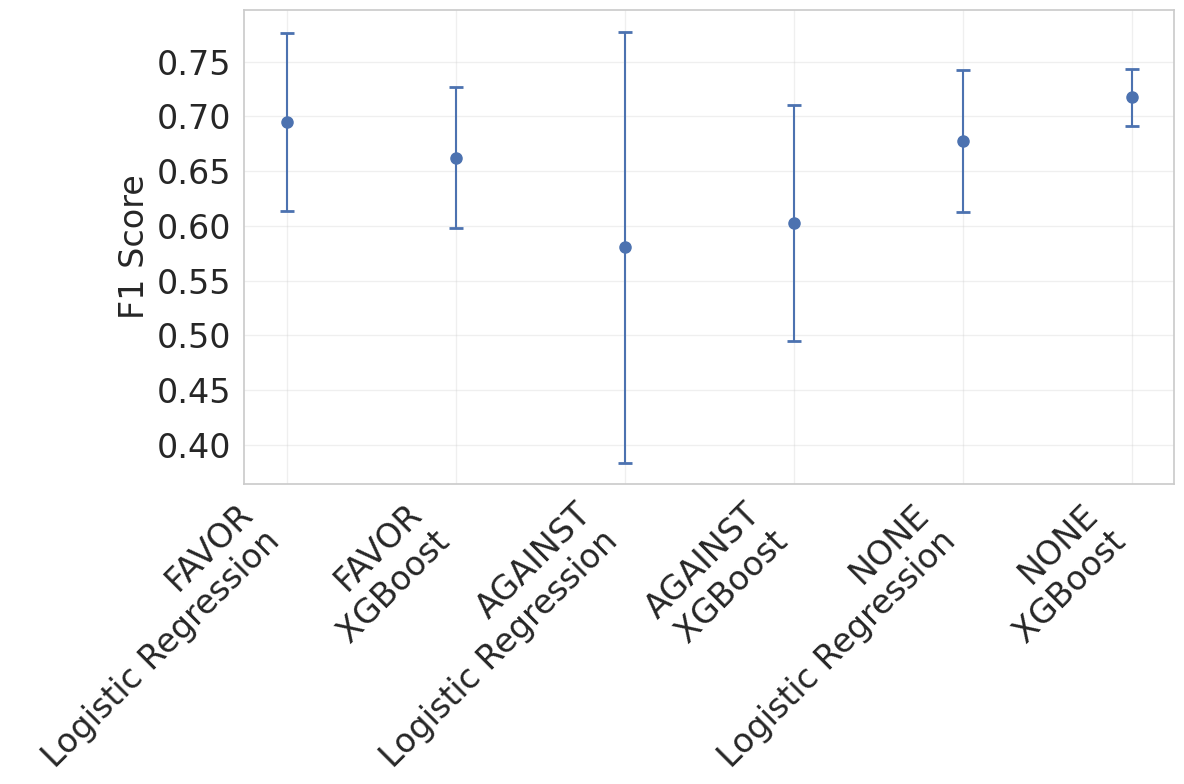


✅ 13-iteration multi-undersampling analysis completed!
📊 Results saved in 'final_analysis_multiple_undersampling/':
   - f1_score_summary_13iterations.csv: Mean ± Std F1 scores across 13 iterations
   - all_f1_scores_13iterations.csv: All individual F1 scores
   - feature_analysis_all_13_iterations.csv: Feature statistics across 13 iterations
   - f1_score_analysis_13iterations.png/pdf: Visualization of F1 score distributions
   - dataset_info_13iterations.csv: Information about each balanced dataset
   - 01_iteration/ through 13_iteration/: Subfolders with top_features_*.csv for each iteration

🎯 Now you have 13 complete experiments with robust statistics!


In [7]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

def load_and_prepare_data(base_dir):
    """Load data and return separate correct and misclassified dataframes for multiple undersampling"""
    paths = ['wtwt_test_processed.csv', 'except_wtwt_test_processed_mapped_data.csv']
    indices = ['wtwt_correctly_classified_indices.npy', 'wtwt_misclassified_indices.npy',
               'except_wtwt_correctly_classified_indices.npy', 'except_wtwt_misclassified_indices.npy']

    df_wtwt = pd.read_csv(os.path.join(base_dir, paths[0]))
    df_except = pd.read_csv(os.path.join(base_dir, paths[1]))

    wtwt_correct = df_wtwt.iloc[np.load(os.path.join(base_dir, indices[0]))]
    wtwt_mis = df_wtwt.iloc[np.load(os.path.join(base_dir, indices[1]))]
    except_correct = df_except.iloc[np.load(os.path.join(base_dir, indices[2]))]
    except_mis = df_except.iloc[np.load(os.path.join(base_dir, indices[3]))]

    df_correct = pd.concat([wtwt_correct, except_correct]).assign(label=1)
    df_mis = pd.concat([wtwt_mis, except_mis]).assign(label=0)
    
    print(f"Correctly classified: {len(df_correct)}, Misclassified: {len(df_mis)}")
    
    return df_correct.reset_index(drop=True), df_mis.reset_index(drop=True)

def create_13_balanced_datasets(df_correct, df_mis, random_state=42):
    """Create 13 balanced datasets - 12 with unique data + 1 with oversampled remainder"""
    balanced_datasets = []
    misclassified_stance_counts = df_mis['stance'].value_counts()
    
    print(f"Creating 13 balanced datasets:")
    print(f"  - 12 iterations using unique correctly classified examples")
    print(f"  - 1 iteration using oversampled remainder + random selection")
    print(f"  - Each iteration will have {len(df_mis)} correctly classified examples")
    
    # Set random seed for reproducibility
    np.random.seed(random_state)
    
    # Create 12 iterations with unique data
    used_correct_indices = set()
    
    for iteration in range(12):
        df_correct_sampled_parts = []
        
        for stance in misclassified_stance_counts.index:
            stance_correct = df_correct[df_correct['stance'] == stance]
            stance_misclassified_count = misclassified_stance_counts[stance]
            
            if len(stance_correct) > 0:
                # Calculate samples per iteration for this stance
                total_available = len(stance_correct)
                samples_per_iteration = min(stance_misclassified_count, total_available // 12)
                
                if samples_per_iteration > 0:
                    start_idx = iteration * samples_per_iteration
                    end_idx = start_idx + samples_per_iteration
                    
                    # Get the indices for this iteration
                    selected_indices = stance_correct.index[start_idx:end_idx]
                    used_correct_indices.update(selected_indices)
                    
                    sampled = stance_correct.loc[selected_indices]
                    df_correct_sampled_parts.append(sampled)
        
        if df_correct_sampled_parts:
            df_correct_sampled = pd.concat(df_correct_sampled_parts)
            df_balanced = pd.concat([df_correct_sampled, df_mis]).reset_index(drop=True)
            balanced_datasets.append(df_balanced)
            print(f"  Iteration {iteration + 1:02d}: {len(df_correct_sampled)} correctly classified examples")
    
    # Create 13th iteration with oversampled remainder
    print(f"\nCreating 13th iteration with oversampling...")
    
    # Get unused examples
    unused_indices = set(df_correct.index) - used_correct_indices
    df_correct_unused = df_correct.loc[list(unused_indices)]
    
    print(f"  Unused correctly classified examples: {len(df_correct_unused)}")
    print(f"  Need to create: {len(df_mis)} examples for balanced dataset")
    
    # Create 13th iteration by stance
    df_correct_13th_parts = []
    
    for stance in misclassified_stance_counts.index:
        stance_unused = df_correct_unused[df_correct_unused['stance'] == stance]
        stance_misclassified_count = misclassified_stance_counts[stance]
        target_count = stance_misclassified_count
        
        if len(stance_unused) > 0:
            if len(stance_unused) >= target_count:
                # If we have enough unused examples, sample without replacement
                sampled_13th = stance_unused.sample(n=target_count, random_state=random_state)
            else:
                # If we don't have enough, use all unused + oversample from all available
                stance_all = df_correct[df_correct['stance'] == stance]
                needed_additional = target_count - len(stance_unused)
                
                # Sample additional examples from all available examples for this stance
                additional_sampled = stance_all.sample(n=needed_additional, 
                                                     replace=True, 
                                                     random_state=random_state + stance)
                
                sampled_13th = pd.concat([stance_unused, additional_sampled])
                print(f"    {stance}: {len(stance_unused)} unused + {needed_additional} oversampled = {len(sampled_13th)}")
            
            df_correct_13th_parts.append(sampled_13th)
        else:
            # If no unused examples for this stance, sample from all available
            stance_all = df_correct[df_correct['stance'] == stance]
            if len(stance_all) > 0:
                sampled_13th = stance_all.sample(n=target_count, 
                                               replace=True, 
                                               random_state=random_state + stance)
                df_correct_13th_parts.append(sampled_13th)
                print(f"    {stance}: 0 unused, sampled {len(sampled_13th)} with replacement")
    
    if df_correct_13th_parts:
        df_correct_13th = pd.concat(df_correct_13th_parts).reset_index(drop=True)
        df_balanced_13th = pd.concat([df_correct_13th, df_mis]).reset_index(drop=True)
        balanced_datasets.append(df_balanced_13th)
        print(f"  Iteration 13: {len(df_correct_13th)} correctly classified examples (with oversampling)")
    
    # Verify all datasets are properly balanced
    print(f"\nDataset verification:")
    for i, dataset in enumerate(balanced_datasets):
        correct_count = len(dataset[dataset['label'] == 1])
        incorrect_count = len(dataset[dataset['label'] == 0])
        print(f"  Dataset {i+1:02d}: {correct_count} correct, {incorrect_count} incorrect")
    
    return balanced_datasets

def save_top_features_for_iteration(df_stance, feature_cols, models, stance_name, iteration_dir):
    """Save top features analysis for a single iteration - similar to original format"""
    X = df_stance[feature_cols]
    y = df_stance['label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
    X_test_scaled = scaler.transform(imputer.transform(X_test))

    top_features = set()
    feature_df_list = []

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        
        if hasattr(model, 'coef_'):
            # Retain signed coefficients, sorted by absolute magnitude
            importance = pd.Series(model.coef_[0], index=feature_cols)
            importance = importance.reindex(importance.abs().sort_values(ascending=False).index).head(44)
        else:
            importance = pd.Series(model.feature_importances_, index=feature_cols).nlargest(44)

        top_features.update(importance.index)
        importance_df = importance.reset_index().rename(columns={'index': 'feature', 0: 'importance'})
        importance_df['model'] = name
        feature_df_list.append(importance_df)

    # Calculate feature statistics
    stats_results = []
    for feature in top_features:
        correct_vals = df_stance[df_stance.label == 1][feature].dropna()
        mis_vals = df_stance[df_stance.label == 0][feature].dropna()

        if len(correct_vals) > 1 and len(mis_vals) > 1:
            _, p_value = ttest_ind(correct_vals, mis_vals)
            significance = '*' if p_value < 0.05 else ''
            stats_results.append({
                'feature': feature, 
                'p_value': p_value, 
                'significance': significance,
                'correct_mean_std': f"{correct_vals.mean().round(4)} ± {correct_vals.std().round(4)}",
                'incorrect_mean_std': f"{mis_vals.mean().round(4)} ± {mis_vals.std().round(4)}"
            })

    stats_df = pd.DataFrame(stats_results)

    # Create final dataframe in the same format as original
    all_importance_df = pd.concat(feature_df_list).pivot(index='feature', columns='model', values='importance').reset_index()
    final_df = all_importance_df.merge(stats_df, on='feature', how='left')
    final_df['feature'] = final_df.apply(lambda row: f"{row['feature']}{row['significance']}", axis=1)
    final_df.drop(columns=['p_value', 'significance'], inplace=True)

    # Save the file
    final_df.to_csv(os.path.join(iteration_dir, f'top_features_{stance_name}.csv'), index=False)

def run_multiple_analysis_with_features(balanced_datasets, output_dir):
    """Run analysis on multiple balanced datasets and save top features for each iteration"""
    stances = [("All_Stances", None), ("FAVOR", 1), ("AGAINST", 0), ("NONE", 2)]
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'XGBoost': XGBClassifier(eval_metric='logloss')
    }

    os.makedirs(output_dir, exist_ok=True)
    
    # Get feature columns from first dataset
    feature_cols = [
        c for c in balanced_datasets[0].columns
        if c not in ['target', 'text', 'stance', 'label', 'dataset', 'topic', 'split', 'index']
        and pd.api.types.is_numeric_dtype(balanced_datasets[0][c])
    ]
    
    # Store F1 scores across all iterations
    f1_results = {stance_name: {model_name: [] for model_name in models.keys()} for stance_name, _ in stances}
    all_feature_results = []
    
    print(f"Running analysis on {len(balanced_datasets)} balanced datasets...")
    
    for iteration, df in enumerate(balanced_datasets):
        print(f"\n--- Iteration {iteration + 1}/{len(balanced_datasets)} ---")
        
        # Create subdirectory for this iteration
        iteration_num = iteration + 1
        iteration_dir = os.path.join(output_dir, f"{iteration_num:02d}_iteration")
        os.makedirs(iteration_dir, exist_ok=True)
        
        for stance_name, stance_val in stances:
            df_stance = df if stance_val is None else df[df['stance'] == stance_val]

            if df_stance['label'].nunique() < 2:
                print(f"Skipping {stance_name} - insufficient class diversity")
                continue

            # Save top features analysis for this stance and iteration
            save_top_features_for_iteration(df_stance, feature_cols, models, stance_name, iteration_dir)

            X = df_stance[feature_cols]
            y = df_stance['label']

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
                                                              random_state=42, stratify=y)
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
            X_test_scaled = scaler.transform(imputer.transform(X_test))

            for name, model in models.items():
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                f1 = f1_score(y_test, y_pred)
                f1_results[stance_name][name].append(f1)
                print(f"  {stance_name} - {name} F1 Score: {f1:.4f}")

            # Calculate feature statistics for this iteration
            for feature in feature_cols:
                correct_vals = df_stance[df_stance.label == 1][feature].dropna()
                mis_vals = df_stance[df_stance.label == 0][feature].dropna()

                if len(correct_vals) > 1 and len(mis_vals) > 1:
                    _, p_value = ttest_ind(correct_vals, mis_vals)
                    significance = '*' if p_value < 0.05 else ''
                    
                    all_feature_results.append({
                        'iteration': iteration_num,
                        'stance': stance_name,
                        'feature': feature,
                        'correct_mean': correct_vals.mean(),
                        'incorrect_mean': mis_vals.mean(),
                        'correct_std': correct_vals.std(),
                        'incorrect_std': mis_vals.std(),
                        'p_value': p_value,
                        'significant': significance
                    })
        
        print(f"  Saved top_features_*.csv files in {iteration_dir}/")
    
    # Calculate and display summary statistics
    print("\n" + "="*80)
    print("SUMMARY: F1 SCORE STATISTICS ACROSS ALL 13 ITERATIONS")
    print("="*80)
    
    summary_results = []
    for stance_name, _ in stances:
        for model_name in models.keys():
            f1_scores = f1_results[stance_name][model_name]
            if f1_scores:  # Check if we have results for this combination
                mean_f1 = np.mean(f1_scores)
                std_f1 = np.std(f1_scores)
                print(f"{stance_name} - {model_name}:")
                print(f"  Mean F1: {mean_f1:.4f} ± {std_f1:.4f}")
                print(f"  Range: [{min(f1_scores):.4f}, {max(f1_scores):.4f}]")
                print(f"  All scores: {[round(f1, 4) for f1 in f1_scores]}")
                
                summary_results.append({
                    'Stance': stance_name,
                    'Model': model_name,
                    'Mean_F1': round(mean_f1, 4),
                    'Std_F1': round(std_f1, 4),
                    'Min_F1': round(min(f1_scores), 4),
                    'Max_F1': round(max(f1_scores), 4),
                    'N_Iterations': len(f1_scores)
                })
        print()
    
    # Save detailed results
    summary_df = pd.DataFrame(summary_results)
    summary_df.to_csv(os.path.join(output_dir, 'f1_score_summary_13iterations.csv'), index=False)
    
    # Save all F1 scores for further analysis
    detailed_f1_data = []
    for stance_name, _ in stances:
        for model_name in models.keys():
            for i, f1 in enumerate(f1_results[stance_name][model_name]):
                detailed_f1_data.append({
                    'Iteration': i + 1,
                    'Stance': stance_name,
                    'Model': model_name,
                    'F1_Score': f1
                })
    
    detailed_f1_df = pd.DataFrame(detailed_f1_data)
    detailed_f1_df.to_csv(os.path.join(output_dir, 'all_f1_scores_13iterations.csv'), index=False)
    
    # Save feature analysis results
    feature_df = pd.DataFrame(all_feature_results)
    feature_df.to_csv(os.path.join(output_dir, 'feature_analysis_all_13_iterations.csv'), index=False)
    
    # Create visualization of F1 score distributions
    create_f1_visualization(summary_df, output_dir)
    
    return summary_df, detailed_f1_df, feature_df

def create_f1_visualization(summary_df, output_dir):
    """Create visualization of F1 score results - Only Plot 4 (Mean ± Std) without All_Stances"""
    
    # Filter out All_Stances rows
    filtered_df = summary_df[summary_df['Stance'] != 'All_Stances'].copy()
    
    # Create single plot instead of 2x2 subplot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Plot 4: Mean ± Std visualization (only this one, without All_Stances)
    x_pos = np.arange(len(filtered_df))
    labels = [f"{row['Stance']}\n{row['Model']}" for _, row in filtered_df.iterrows()]
    
    ax.errorbar(x_pos, filtered_df['Mean_F1'], yerr=filtered_df['Std_F1'], 
                fmt='o', capsize=5, capthick=2, markersize=8)
    ax.set_ylabel('F1 Score', fontsize=24)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'f1_score_analysis_13iterations.png'), dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, 'f1_score_analysis_13iterations.pdf'), dpi=600, bbox_inches='tight')
    plt.show()
    
    


# Main execution
if __name__ == '__main__':
    base_dir = "evaluation_results"
    output_dir = "final_analysis_multiple_undersampling"

    # Load data
    df_correct, df_mis = load_and_prepare_data(base_dir)
    
    # Create 13 balanced datasets (12 unique + 1 oversampled)
    balanced_datasets = create_13_balanced_datasets(df_correct, df_mis, random_state=42)
    
    print(f"\nCreated {len(balanced_datasets)} balanced datasets")
    total_used = sum(len(df[df['label'] == 1]) for df in balanced_datasets)
    unique_used = 12 * len(df_mis)  # First 12 iterations use unique data
    oversampled = total_used - unique_used
    print(f"Unique correctly classified examples used: {unique_used} out of {len(df_correct)}")
    print(f"Oversampled examples in 13th iteration: {oversampled}")
    print(f"Total utilization: {100*total_used/(len(df_correct)*13):.1f}% across all iterations")
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Save information about the datasets
    dataset_info = []
    for i, df in enumerate(balanced_datasets):
        info = {
            'Dataset': i + 1,
            'Total_Size': len(df),
            'Correct_Count': len(df[df['label'] == 1]),
            'Incorrect_Count': len(df[df['label'] == 0]),
            'Balance_Ratio': len(df[df['label'] == 1]) / len(df[df['label'] == 0]),
            'Type': 'Unique_Data' if i < 12 else 'Oversampled'
        }
        dataset_info.append(info)
        
        # Add stance distribution
        stance_counts = df['stance'].value_counts()
        for stance, count in stance_counts.items():
            info[f'{stance}_count'] = count
    
    dataset_info_df = pd.DataFrame(dataset_info)
    dataset_info_df.to_csv(os.path.join(output_dir, 'dataset_info_13iterations.csv'), index=False)
    print(f"\nDataset composition saved to {output_dir}/dataset_info_13iterations.csv")
    
    # Run analysis on all 13 datasets
    summary_df, detailed_f1_df, feature_df = run_multiple_analysis_with_features(balanced_datasets, output_dir)
    
    print(f"\n✅ 13-iteration multi-undersampling analysis completed!")
    print(f"📊 Results saved in '{output_dir}/':")
    print(f"   - f1_score_summary_13iterations.csv: Mean ± Std F1 scores across 13 iterations")
    print(f"   - all_f1_scores_13iterations.csv: All individual F1 scores")
    print(f"   - feature_analysis_all_13_iterations.csv: Feature statistics across 13 iterations")
    print(f"   - f1_score_analysis_13iterations.png/pdf: Visualization of F1 score distributions")
    print(f"   - dataset_info_13iterations.csv: Information about each balanced dataset")
    print(f"   - 01_iteration/ through 13_iteration/: Subfolders with top_features_*.csv for each iteration")
    print(f"\n🎯 Now you have 13 complete experiments with robust statistics!")